In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# читаем данные
df = pd.read_csv('data.csv')

# Вывел несколько первых строк
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [5]:
# Проверяем формат столбцов

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


In [7]:
# Сразу переведем столбец "Дата" в правильный формат

In [8]:
df["Дата"] = pd.to_datetime(df["Дата"])
df["Дата"].dtype

dtype('<M8[ns]')

In [9]:
# Анализ динамики продаж по дням

In [10]:
grouped_df = (
    df.groupby("Дата")
      .size()
      .reset_index(name="Количество")
      .sort_values("Дата")
)

In [11]:
# Вывел несколько первых строк

In [12]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


In [13]:
# график продаж у `grouped_df`

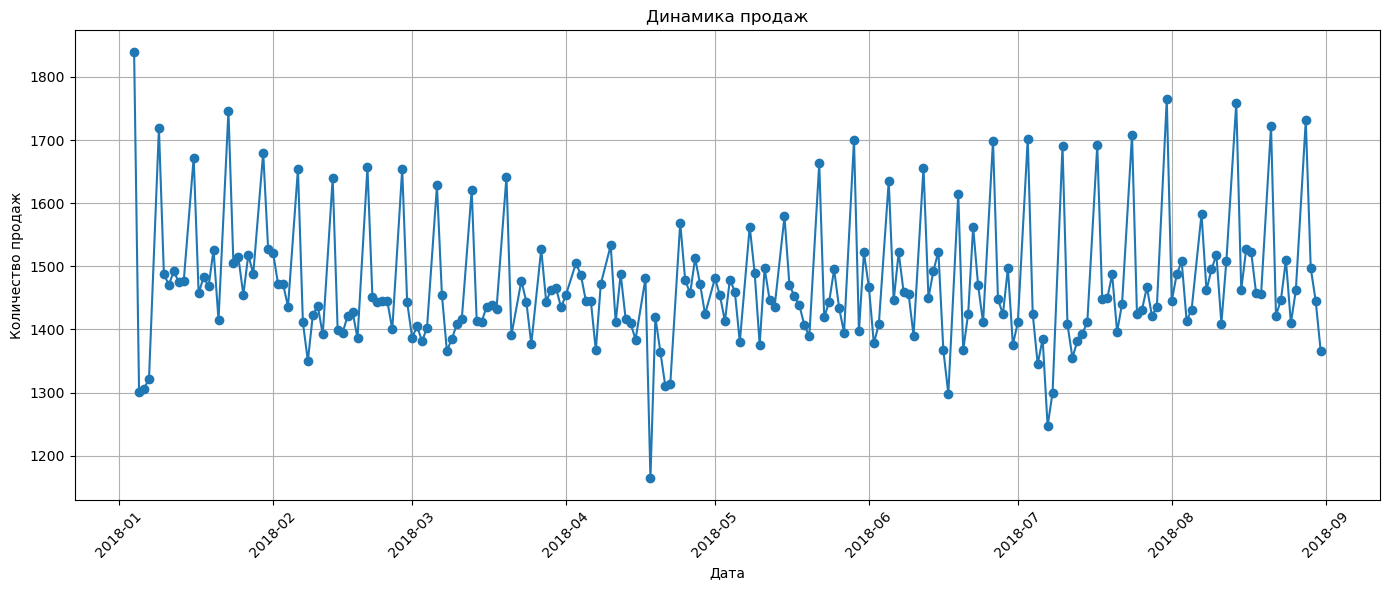

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    grouped_df["Дата"],
    grouped_df["Количество"],
    marker="o"
)

plt.title("Динамика продаж")
plt.xlabel("Дата")
plt.ylabel("Количество продаж")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Инсайты по графику

In [16]:
#График отображает ежедневное количество продаж за период примерно с января по конец августа 2018 года.
#Количество продаж в большинстве дней находится в диапазоне: 1350–1550 продаж в день
#Средний уровень визуально составляет около: 1450 продаж в день
#В течение всего периода продажи остаются относительно стабильными:в начале года продажи находятся на уровне 1400–1500;
#к концу периода средний уровень практически не изменяется;сильного роста или падения бизнеса не видно.
#Это говорит о стабильном спросе.
#На графике хорошо заметна регулярная цикличность.Практически каждую неделю наблюдаются:один или несколько пиков продаж;
#затем возврат к обычному уровню.
#Продажи демонстрируют стабильную динамику без выраженного долгосрочного тренда. 
#На графике прослеживается регулярная сезонность с повторяющимися недельными пиками.
#В целом бизнес показывает устойчивый спрос и отсутствие признаков системного снижения продаж.



In [17]:
# Найдем строку, у которой максимальный выброс по количеству продаж

In [21]:
Q1 = grouped_df['Количество'].quantile(0.25)
Q3 = grouped_df['Количество'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = grouped_df[
    (grouped_df['Количество'] > upper_bound) |
    (grouped_df['Количество'] < lower_bound)
]


max_outlier = outliers.loc[
    outliers['Количество'].idxmax()
]

max_outlier

Дата          2018-01-04 00:00:00
Количество                   1840
Name: 0, dtype: object

In [22]:
# Найдем топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [23]:
# Фильтр
filtered = df[
    (df["Склад"] == 3) &
    (df["Дата"].dt.month.isin([6, 7, 8])) &
    (df["Дата"].dt.dayofweek == 2)   # среда
]
top_product = (
    filtered
    .groupby("Номенклатура")["Количество"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print(top_product)

Номенклатура
product_1    2267
Name: Количество, dtype: int64


In [24]:
#Скачаю данные из сайта https://rp5.ru/Архив_погоды_в_Астане (скачал исходные данные, и далее преобразовал так, 
#чтобы мы имели Дату и Среднюю температуру за день), объединил таблицу температуры с `grouped_df`, 
#и нарисовал график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [25]:
weather_df = pd.read_csv(
    "weather.csv",
    sep=";",
    encoding="utf-8",
    skiprows=6,
    quotechar='"',
    index_col=False
)

In [26]:
weather_df["Местное время в Астане"] = pd.to_datetime(
    weather_df["Местное время в Астане"],
    format="%d.%m.%Y %H:%M"
)

weather_df["Дата"] = weather_df["Местное время в Астане"].dt.normalize()

weather_df[["Местное время в Астане", "T"]].head()

,Местное время в Астане,T
0,2018-08-31 23:00:00,8.2
1,2018-08-31 20:00:00,9.6
2,2018-08-31 17:00:00,11.3
3,2018-08-31 14:00:00,12.3
4,2018-08-31 11:00:00,13.2


In [27]:
temp_df = (
    weather_df
    .groupby('Дата', as_index=False)['T']
    .mean()
)
temp_df.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [28]:
print(temp_df['Дата'].min())
print(temp_df['Дата'].max())

2018-01-04 00:00:00
2018-08-31 00:00:00


In [29]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])

In [30]:
merged_df = grouped_df.merge(
    temp_df,
    on='Дата',
    how='left'
)
merged_df.head()

,Дата,Количество,T
0,2018-01-04,1840,-14.0750
1,2018-01-05,1301,-16.8625
2,2018-01-06,1306,-13.3000
3,2018-01-07,1322,-12.7500
4,2018-01-09,1719,-6.2500


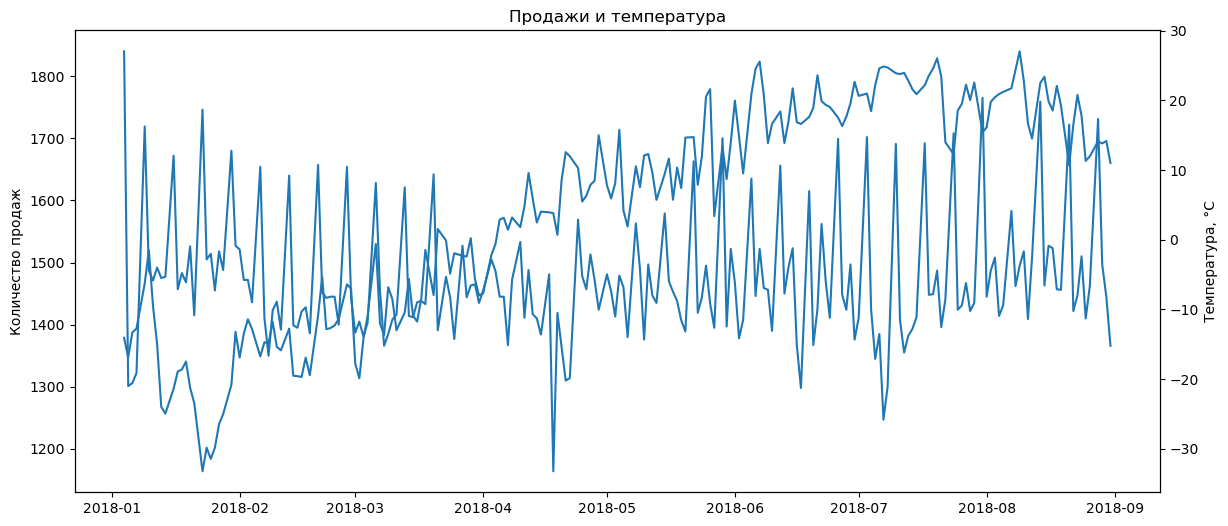

In [35]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    merged_df['Дата'],
    merged_df['Количество'],
    label='Количество продаж'
)

ax1.set_ylabel('Количество продаж')

ax2 = ax1.twinx()

ax2.plot(
    merged_df['Дата'],
    merged_df['T'],
    label='Температура'
)

ax2.set_ylabel('Температура, °C')

plt.title('Продажи и температура')
plt.show()

In [ ]:
#Продажи колеблются примерно от 1200 до 1850 заказов.
#Явного роста продаж вместе с ростом температуры не наблюдается.
#Температура растет плавно, а продажи меняются скачкообразно.
#Высокие продажи встречаются как при отрицательных, так и при положительных температурах.
#Визуально сильной зависимости между температурой и продажами нет.

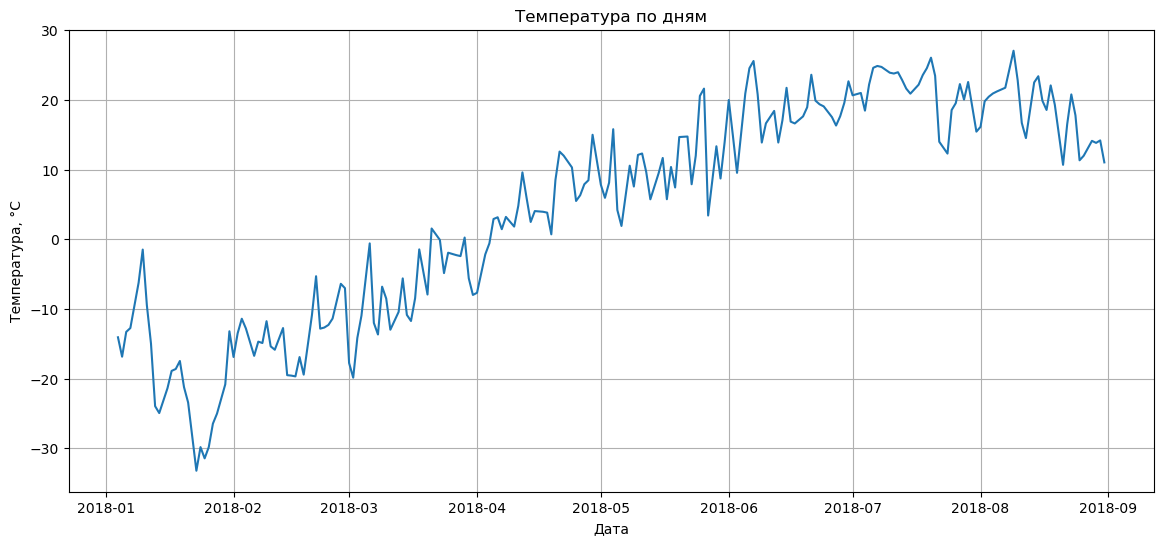

In [32]:
plt.figure(figsize=(14,6))

plt.plot(
    merged_df['Дата'],
    merged_df['T']
)

plt.title('Температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True)

plt.show()

In [ ]:
#С января по июль наблюдается устойчивый рост температуры.
#Минимальное значение около -33°C в январе.
#Максимальные значения достигают 25–27°C летом.
#После середины июля температура стабилизируется на высоком уровне.
#Есть краткосрочные колебания, но общий тренд остается восходящим.